<a id="top"></a>
# Estimating Galaxy Cluster Masses with Convolutional Neural Networks

***

## Imports
This notebook uses the following:
- *numpy* to handle array functions
- *astropy.io fits* for accessing FITS files
- *matplotlib.pyplot* for plotting data
- *keras* for building the CNN

In [20]:
#%matplotlib widget
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import keras
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D
from keras.layers import GlobalAveragePooling2D


# Approch 1

## Cluster Mass Regression

This notebook trains a CNN to estimate cluster mass from X-ray images. The key evaluation unit is the cluster, not an individual image, because each cluster has up to three lines of sight.

### 1. Load the data

The FITS file contains the X-ray images and metadata, including `cluster_id`, `view_los`, `log_M500`, and the original train/validation/test flags.

In [2]:
filename = r'/Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/cluster_TNG_data.fits'
hdul = fits.open(filename)
image_size = hdul[1].data.shape[1]

### 2. Prepare the baseline split

The original split is retained for the baseline model. The cross-validation model below uses cluster-level folds instead, preventing different views of one cluster from appearing in both training and validation data.

In [3]:
train_ind = np.argwhere(hdul[2].data['train'] == 1)
train_X = hdul[1].data[train_ind].reshape(-1, image_size, image_size, 1)
train_Y = hdul[2].data['log_M500'][train_ind]

val_ind = np.argwhere(hdul[2].data['validate'] == 1)
val_X = hdul[1].data[val_ind].reshape(-1, image_size, image_size, 1)
val_Y = hdul[2].data['log_M500'][val_ind]

test_ind = np.argwhere(hdul[2].data['test'] == 1)
test_X = hdul[1].data[test_ind].reshape(-1, image_size, image_size, 1)
test_Y = hdul[2].data['log_M500'][test_ind]

ML models often converge faster when the output is _roughly_ between 0 and 1. Next, let's perform a normalization that will speed up the training process a bit -- calculate the minimum log(mass) and subtract it from the Y labels as a change of units.  We'll put it back, later in the notebook, just before we plot the results.  

We can simply subtract off a constant value because our output doesn't have a large dynamical range, but there may be cases where you want to handle this more carefully and force all of your labels to be strictly in the (0,1) interval.  

In [4]:
norm = np.nanmin(hdul[2].data['log_M500'])
train_Y -= norm
val_Y -= norm
test_Y -= norm

### 3. Build a CNN in Keras

Here, we will build the model described in Section 2.2 of [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract)

Further details about Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout, and Dense layers can be found in the [Keras Layers Documentation](https://keras.io/api/layers/).  Further details about the relu activation function can be found in the [Keras Activation Function Documentation](https://keras.io/api/layers/activations/).

In [5]:
input_shape = (image_size, image_size, 1)
model = Sequential([
    Input(shape=input_shape),
    Conv2D(16, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    GlobalAveragePooling2D(),
    Dropout(0.1),
    Dense(200, activation='relu'),
    Dropout(0.1),
    Dense(100, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear')
])

2026-08-28 01:43:33.033691: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-08-28 01:43:33.033727: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-08-28 01:43:33.033734: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1787852613.033909  862879 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1787852613.034119  862879 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### 4. Compile the CNN

Next, we compile the model.  As in [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract), we select the Adam opmimizer (with a learning rate that is slightly decreased from the default rate) and the mean squared error loss function.

You can learn more about [optimizers](https://keras.io/api/optimizers/) and more about [loss functions for regression tasks](https://keras.io/api/losses/) in the [Keras documentation](https://keras.io/)

In [6]:
model.compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam(learning_rate=0.0002))

### 5. Train the CNN to perform a regression task

We will start with training for 5 epochs, but this almost certainly won't be long enough to get great results.  Once you've run your model and evaluated the fit, you can come back here and run the next cell again for 100 epochs or longer.  

You can learn more about model.fit [here](https://keras.rstudio.com/reference/fit.html)

In [21]:
epoch_options = [10, 50, 100, 150]
batch_size = 32 # Same batch size as the original notebook.

from pathlib import Path
output_dir = Path('approach1_outputs')
output_dir.mkdir(exist_ok=True)

models_by_epoch = {}
histories_by_epoch = {}
predictions_by_epoch = {}
metrics_by_epoch = []

# The original recorded run used CPU execution. Keep this comparison on CPU because
# the current Metal runtime is numerically unstable with these raw image inputs.
with tf.device('/CPU:0'):
    comparison_model = Sequential()
    comparison_model.add(Conv2D(16, kernel_size=(3, 3), input_shape=input_shape, activation='relu'))
    comparison_model.add(MaxPooling2D(pool_size=(2, 2)))
    comparison_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
    comparison_model.add(MaxPooling2D(pool_size=(2, 2)))
    comparison_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    comparison_model.add(MaxPooling2D(pool_size=(2, 2)))
    comparison_model.add(GlobalAveragePooling2D())
    comparison_model.add(Dropout(0.1))
    comparison_model.add(Dense(200, activation='relu'))
    comparison_model.add(Dropout(0.1))
    comparison_model.add(Dense(100, activation='relu'))
    comparison_model.add(Dense(20, activation='relu'))
    comparison_model.add(Dense(1, activation='linear'))
    comparison_model.compile(
        loss='mean_squared_error',
        optimizer=keras.optimizers.Adam(learning_rate=0.0002),
    )

    checkpoint_weights = {}

    class EpochCheckpoint(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            completed_epoch = epoch + 1
            if completed_epoch in epoch_options:
                checkpoint_weights[completed_epoch] = [
                    np.array(weight, copy=True) for weight in self.model.get_weights()
                ]

    full_history = comparison_model.fit(
        train_X,
        train_Y,
        batch_size=batch_size,
        verbose=True,
        epochs=max(epoch_options),
        callbacks=[EpochCheckpoint()],
    )

    for epoch_count in epoch_options:
        checkpoint_model = keras.models.clone_model(comparison_model)
        checkpoint_model.set_weights(checkpoint_weights[epoch_count])
        checkpoint_model.compile(
            loss='mean_squared_error',
            optimizer=keras.optimizers.Adam(learning_rate=0.0002),
        )
        checkpoint_history = keras.callbacks.History()
        checkpoint_history.history = {
            key: values[:epoch_count]
            for key, values in full_history.history.items()
        }
        checkpoint_prediction = checkpoint_model.predict(
            test_X, verbose=0, batch_size=batch_size
        ).flatten()
        models_by_epoch[epoch_count] = checkpoint_model
        histories_by_epoch[epoch_count] = checkpoint_history
        predictions_by_epoch[epoch_count] = checkpoint_prediction
        metrics_by_epoch.append({
            'epochs': epoch_count,
            'r2': r2_score(test_Y, checkpoint_prediction),
            'mae': mean_absolute_error(test_Y, checkpoint_prediction),
            'rmse': np.sqrt(mean_squared_error(test_Y, checkpoint_prediction)),
            'bias': np.mean(test_Y - checkpoint_prediction),
            'train_loss': full_history.history['loss'][epoch_count - 1],
        })
        print(f'Captured epoch {epoch_count} checkpoint from the single 150-epoch training run')

# Keep the longest checkpoint as the default for the existing evaluation cells.
epochs = max(epoch_options)
model = models_by_epoch[epochs]
hist = histories_by_epoch[epochs]
prediction = predictions_by_epoch[epochs]

Epoch 1/150


/Users/tripathimihir/miniforge3/envs/a3net/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.4011
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1655
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1100
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1735
Epoch 5/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1040
Epoch 6/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0472
Epoch 7/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0508
Epoch 8/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0422
Epoch 9/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0596
Epoch 10/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0407
Epoch 11/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0352
Epoch 12/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0350
Epoch 13/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0546
Epoch 14/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0321
Epoch 15/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0423
E

### 6. Evaluate the results

Next, we will plot up the true and predicted log(masses).  We have only trained for 5 epochs, so we expect noisy results and catastrophic outliers.  Don't panic -- we will discuss how to fix this in the FAQs. 

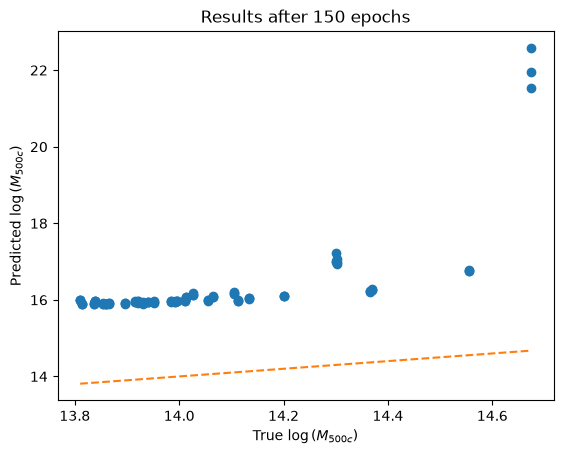

In [8]:
prediction = model.predict(test_X, verbose=0, batch_size=batch_size).flatten()
# Remember when we subtracted off the min in an earlier cell?  In the next line, we're putting it back in!
plt.scatter(test_Y + norm, prediction + norm, c='C0', label='model predictions')
x = np.linspace(np.min(test_Y+norm), np.max(test_Y+norm), 100)
plt.plot(x,x,ls='--', c='C1', label='one-to-one line')
plt.xlabel('True '+r'$\log\left(M_{500c}\right)$')
plt.ylabel('Predicted '+r'$\log\left(M_{500c}\right)$')
plt.title('Results after {:.0f} epochs'.format(epochs))
plt.savefig('results_after_{}.png'.format(epochs), dpi=300)
plt.show()


# Approach 1 outputs
All models, metrics, histories, plots, and plotting scripts are saved under `approach1_outputs`.

The epoch comparison preserves the original paper notebook exactly: the same fixed train/test arrays, CNN architecture, optimizer, batch size, raw inputs, and training-only loss. One 150-epoch run supplies checkpoints at epochs `10`, `50`, `100`, and `150`, so epoch count is the only comparison variable.

For every checkpoint, the notebook saves:

- `baseline_model_epoch_<N>.keras`
- `training_history_epoch_<N>.npz`, containing training `loss`
- `baseline_diagnostics_epoch_<N>.png`, containing predictions and training loss

The performance comparison is saved as `baseline_performance_vs_epochs.png`.

In [9]:
from pathlib import Path
import json
output_dir = Path('approach1_outputs')
output_dir.mkdir(exist_ok=True)


In [22]:
metrics_by_epoch_df = pd.DataFrame(metrics_by_epoch)
metrics_by_epoch_df.to_csv(output_dir / 'baseline_metrics_by_epoch.csv', index=False)

for epoch_count in epoch_options:
    epoch_model = models_by_epoch[epoch_count]
    epoch_history = histories_by_epoch[epoch_count]
    epoch_model.save(output_dir / f'baseline_model_epoch_{epoch_count}.keras')
    np.savez(
        output_dir / f'training_history_epoch_{epoch_count}.npz',
        loss=np.asarray(epoch_history.history.get('loss', [])),
    )

(output_dir / 'run_metadata.json').write_text(json.dumps({
    'approach': 1,
    'description': 'Original fixed train/validation/test split and training-only loss',
    'epoch_options': epoch_options,
    'batch_size': batch_size,
    'comparison': 'single 150-epoch trajectory with checkpoints',
    'device': 'CPU:0 for reproducibility with original recorded run',
}, indent=2))
print(f'Saved epoch-tagged models, histories, and metrics to {output_dir.resolve()}')

Saved epoch-tagged models, histories, and metrics to /Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/approach1_outputs


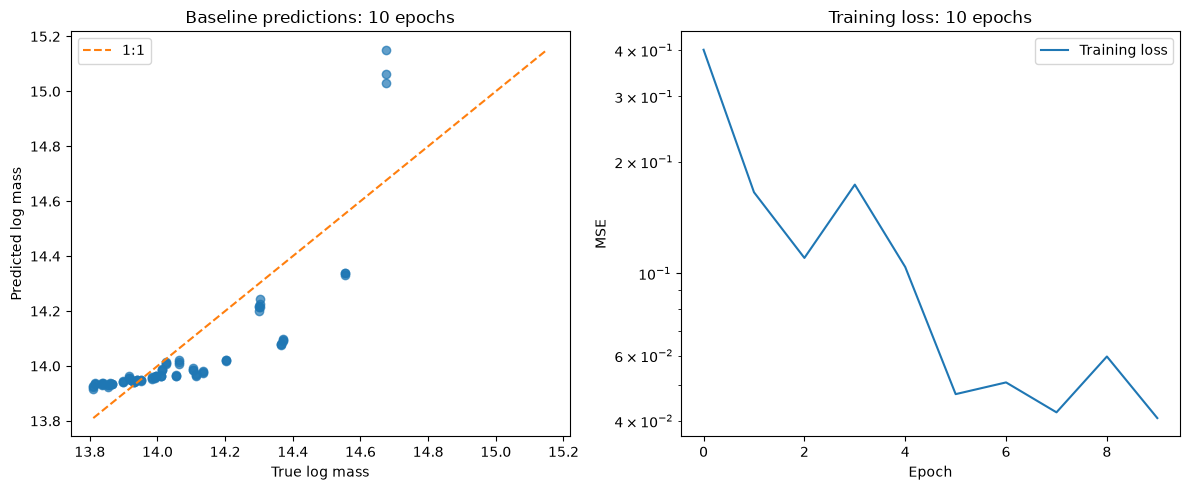

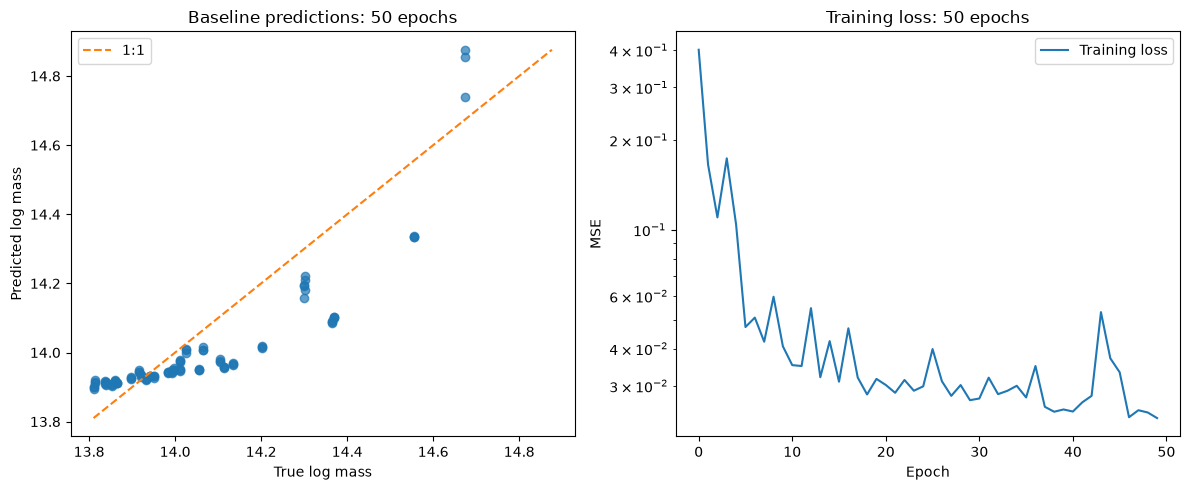

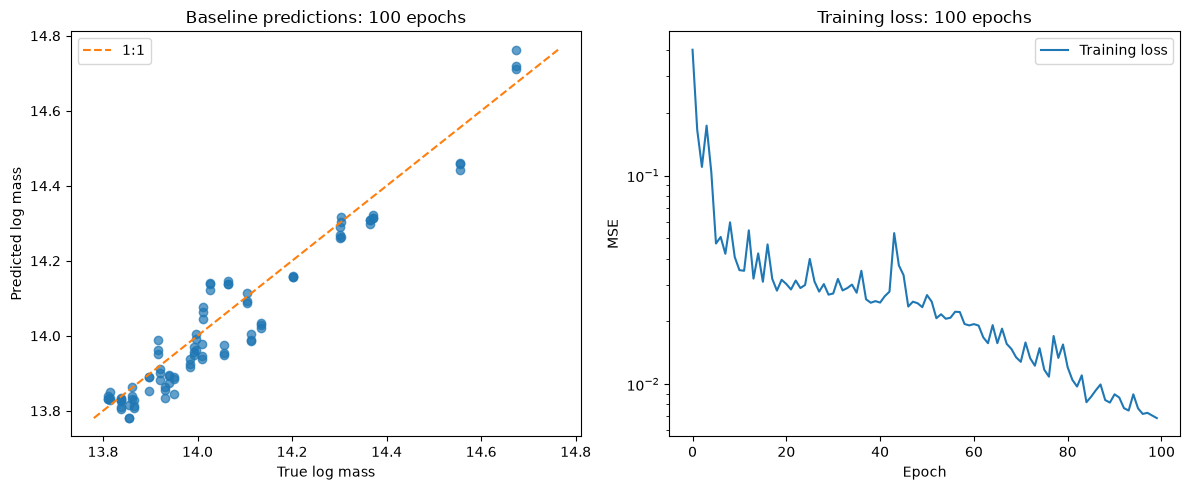

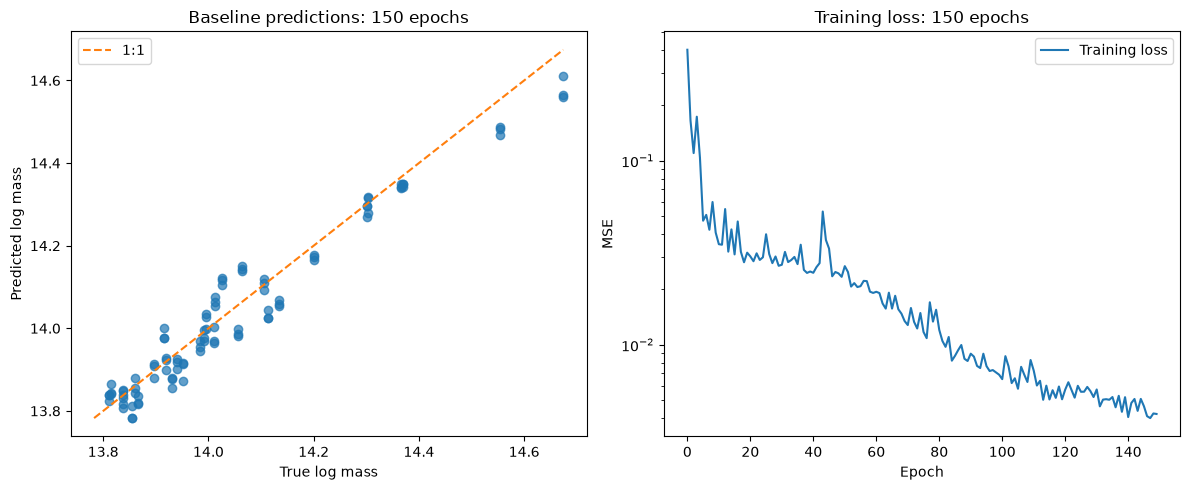

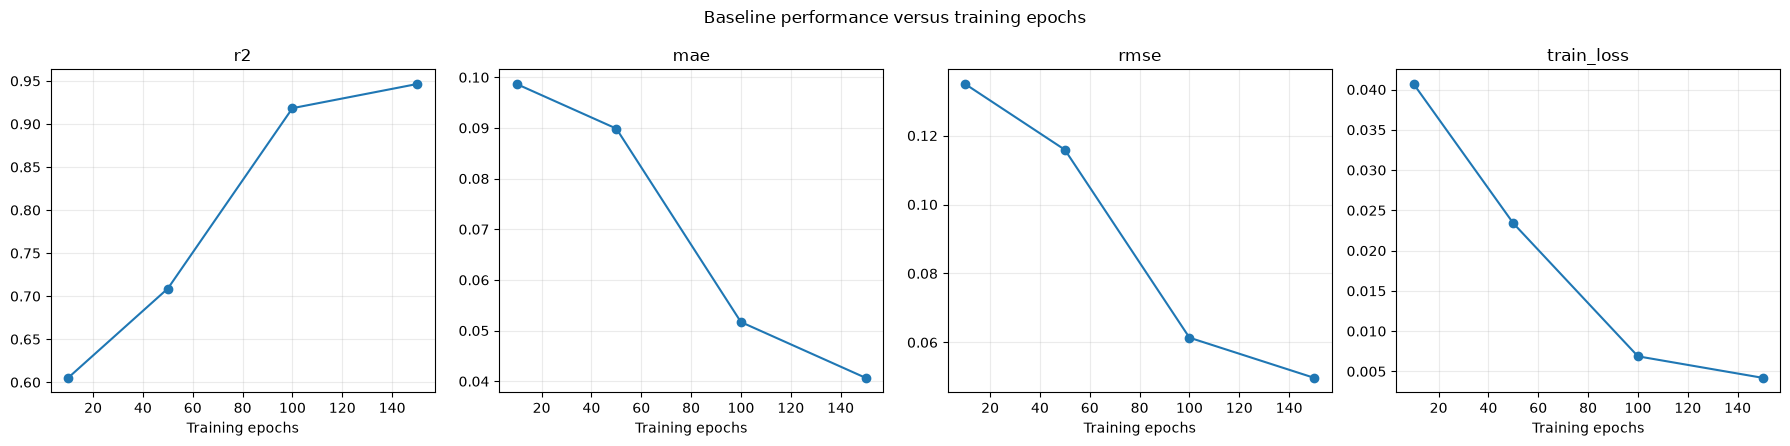

Saved epoch-tagged baseline diagnostic plots and comparison plot


In [24]:
for epoch_count in epoch_options:
    epoch_prediction = predictions_by_epoch[epoch_count]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(test_Y + norm, epoch_prediction + norm, c='C0', alpha=0.7)
    plot_min = min(np.min(test_Y + norm), np.min(epoch_prediction + norm))
    plot_max = max(np.max(test_Y + norm), np.max(epoch_prediction + norm))
    axes[0].plot([plot_min, plot_max], [plot_min, plot_max], '--', c='C1', label='1:1')
    axes[0].set(xlabel='True log mass', ylabel='Predicted log mass',
                title=f'Baseline predictions: {epoch_count} epochs')
    axes[0].legend()

    epoch_history = histories_by_epoch[epoch_count].history
    axes[1].plot(epoch_history.get('loss', []), label='Training loss')
    axes[1].set(xlabel='Epoch', ylabel='MSE',
                title=f'Training loss: {epoch_count} epochs')
    axes[1].set_yscale('log')
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(output_dir / f'baseline_diagnostics_epoch_{epoch_count}.png', dpi=200,
                bbox_inches='tight')
    plt.show()
    plt.close(fig)

    loss_fig, loss_axis = plt.subplots(figsize=(7, 5))
    loss_axis.plot(epoch_history.get('loss', []), label='Training loss')
    loss_axis.set(xlabel='Epoch', ylabel='MSE',
                  title=f'Training loss: {epoch_count} epochs')
    loss_axis.set_yscale('log')
    loss_axis.legend()
    loss_fig.tight_layout()
    loss_fig.savefig(output_dir / f'loss_curves_epoch_{epoch_count}.png', dpi=200,
                     bbox_inches='tight')
    plt.close(loss_fig)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for axis, metric in zip(axes, ['r2', 'mae', 'rmse', 'train_loss']):
    axis.plot(metrics_by_epoch_df['epochs'], metrics_by_epoch_df[metric], 'o-', color='C0')
    axis.set(title=metric, xlabel='Training epochs')
    axis.grid(alpha=0.25)
fig.suptitle('Baseline performance versus training epochs')
fig.tight_layout()
fig.savefig(output_dir / 'baseline_performance_vs_epochs.png', dpi=200)
plt.show()
plt.close(fig)
print('Saved epoch-tagged baseline diagnostic plots and comparison plot')

### 7. Baseline limitation: diagnose cluster leakage and correlated views

Approach 1 treats each image row as independent. The following audit shows whether different views of the same cluster are distributed across train, validation, and test, and whether predictions are consistent across the three views. If a cluster appears in multiple splits, the fixed-split test score can be optimistic because the model has seen related views during training.

Clusters represented in more than one split: 0
Fraction of clusters crossing splits: 0.0%
Rows assigned to more than one split: 0


split,train,validate,test,n_splits
cluster_id,,,,


Number of test views per cluster:


n_test_views
3    31
Name: clusters, dtype: int64

Clusters with multiple test views:


,cluster_id,n_test_views,true_log_mass,mean_predicted_log_mass,prediction_spread,mean_error,error_spread
0,9,3,14.674312,22.024780,0.528799,7.350468,0.528799
1,19,3,14.554651,16.764374,0.013541,2.209723,0.013541
2,29,3,14.201312,16.105118,0.002911,1.903806,0.002911
3,39,3,14.370312,16.261581,0.015621,1.891270,0.015621
4,49,3,14.365849,16.223398,0.018156,1.857551,0.018156
5,59,3,14.134748,16.033895,0.010914,1.899148,0.010914
6,69,3,14.303076,16.991598,0.066344,2.688522,0.066344
7,79,3,14.300480,17.065849,0.131770,2.765370,0.131770
8,89,3,13.814546,15.900437,0.004279,2.085892,0.004279
9,99,3,13.996302,15.968554,0.003653,1.972252,0.003653


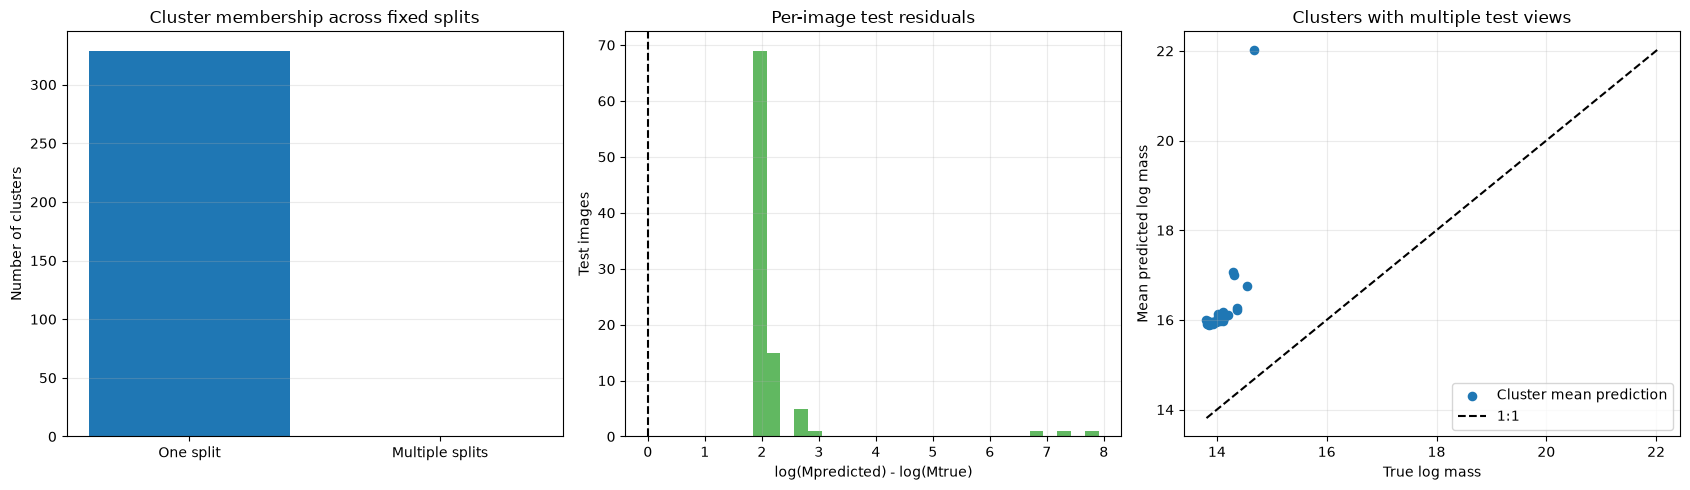

Saved cluster leakage and correlated-view diagnostics


In [12]:
def native_array(values):
    array = np.asarray(values)
    if array.dtype.byteorder not in ('=', '|'):
        array = array.astype(array.dtype.newbyteorder('='))
    return array

metadata = pd.DataFrame({
    'cluster_id': native_array(hdul[2].data['cluster_id']),
    'view_los': native_array(hdul[2].data['view_los']),
    'train': native_array(hdul[2].data['train']),
    'validate': native_array(hdul[2].data['validate']),
    'test': native_array(hdul[2].data['test']),
})

def split_name(row):
    active_splits = [
        name for name in ('train', 'validate', 'test')
        if row[name] == 1
    ]
    return active_splits[0] if len(active_splits) == 1 else 'unused_or_multiple'

metadata['split'] = metadata.apply(split_name, axis=1)
cluster_split_table = pd.crosstab(metadata['cluster_id'], metadata['split'])
cluster_split_table = cluster_split_table.reindex(
    columns=['train', 'validate', 'test'], fill_value=0
)
cluster_split_table['n_splits'] = (cluster_split_table > 0).sum(axis=1)
leaky_clusters = cluster_split_table[cluster_split_table['n_splits'] > 1]

print(f'Clusters represented in more than one split: {len(leaky_clusters)}')
print(f'Fraction of clusters crossing splits: {len(leaky_clusters) / len(cluster_split_table):.1%}')
print('Rows assigned to more than one split:', (metadata['split'] == 'unused_or_multiple').sum())
display(leaky_clusters.head(20))

test_rows = np.asarray(test_ind).ravel()
test_prediction_table = pd.DataFrame({
    'cluster_id': native_array(hdul[2].data['cluster_id'][test_rows]),
    'view_los': native_array(hdul[2].data['view_los'][test_rows]),
    'true_log_mass': np.asarray(test_Y).ravel() + norm,
    'predicted_log_mass': np.asarray(prediction).ravel() + norm,
})
test_prediction_table['error'] = (
    test_prediction_table['predicted_log_mass']
    - test_prediction_table['true_log_mass']
)
cluster_prediction_summary = test_prediction_table.groupby('cluster_id').agg(
    n_test_views=('predicted_log_mass', 'size'),
    true_log_mass=('true_log_mass', 'first'),
    mean_predicted_log_mass=('predicted_log_mass', 'mean'),
    prediction_spread=('predicted_log_mass', 'std'),
    mean_error=('error', 'mean'),
    error_spread=('error', 'std'),
).reset_index()

print('Number of test views per cluster:')
display(cluster_prediction_summary['n_test_views'].value_counts().sort_index().rename('clusters'))
print('Clusters with multiple test views:')
display(cluster_prediction_summary.query('n_test_views > 1').head(20))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].bar(['One split', 'Multiple splits'], [
    len(cluster_split_table) - len(leaky_clusters), len(leaky_clusters)
], color=['C0', 'C3'])
axes[0].set_ylabel('Number of clusters')
axes[0].set_title('Cluster membership across fixed splits')
axes[0].grid(axis='y', alpha=0.25)

axes[1].hist(test_prediction_table['error'], bins=25, alpha=0.75, color='C2')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set(xlabel='log(Mpredicted) - log(Mtrue)', ylabel='Test images',
            title='Per-image test residuals')
axes[1].grid(alpha=0.25)

multi_view = cluster_prediction_summary.query('n_test_views > 1')
if len(multi_view):
    axes[2].scatter(
        multi_view['true_log_mass'], multi_view['mean_predicted_log_mass'],
        s=35, label='Cluster mean prediction'
    )
    plot_min = min(multi_view['true_log_mass'].min(), multi_view['mean_predicted_log_mass'].min())
    plot_max = max(multi_view['true_log_mass'].max(), multi_view['mean_predicted_log_mass'].max())
    axes[2].plot([plot_min, plot_max], [plot_min, plot_max], 'k--', label='1:1')
    axes[2].set(xlabel='True log mass', ylabel='Mean predicted log mass',
                title='Clusters with multiple test views')
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'No clusters have multiple test views', ha='center', va='center')
    axes[2].set_title('Cluster-level test diagnostic')
axes[2].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(output_dir / 'baseline_cluster_leakage_diagnostics.png', dpi=200, bbox_inches='tight')
plt.show()

cluster_split_table.to_csv(output_dir / 'cluster_split_membership.csv')
cluster_prediction_summary.to_csv(output_dir / 'test_cluster_prediction_summary.csv', index=False)
print('Saved cluster leakage and correlated-view diagnostics')

In [ ]:
plot_script = r'''from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path(__file__).resolve().parent
metrics = pd.read_csv(OUTPUT_DIR / 'baseline_metrics_by_epoch.csv')

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for axis, metric in zip(axes, ['r2', 'mae', 'rmse', 'train_loss']):
    axis.plot(metrics['epochs'], metrics[metric], 'o-', color='C0')
    axis.set(title=metric, xlabel='Training epochs')
    axis.grid(alpha=0.25)
fig.suptitle('Baseline performance versus training epochs')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'baseline_performance_vs_epochs.png', dpi=200, bbox_inches='tight')
plt.close(fig)

for epoch_count in metrics['epochs']:
    history = np.load(OUTPUT_DIR / f'training_history_epoch_{int(epoch_count)}.npz')
    fig, axis = plt.subplots(figsize=(7, 5))
    axis.plot(history['loss'], label='Training loss')
    axis.set(xlabel='Epoch', ylabel='MSE', title=f'Training loss: {int(epoch_count)} epochs')
    axis.set_yscale('log')
    axis.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'loss_curves_epoch_{int(epoch_count)}.png', dpi=200, bbox_inches='tight')
    plt.close(fig)
print(f'Plots regenerated in {OUTPUT_DIR}')
'''
(output_dir / 'plot_outputs.py').write_text(plot_script)
print(f'Saved plotting script to {(output_dir / "plot_outputs.py").resolve()}')

Saved plotting script to /Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/approach1_outputs/plot_outputs.py


In [14]:
train_loss_inference = model.evaluate(
    train_X, train_Y, batch_size=batch_size, verbose=0
)

val_loss_inference = model.evaluate(
    val_X, val_Y, batch_size=batch_size, verbose=0
)

print(f'Train MSE: {train_loss_inference:.5f}')
print(f'Validation MSE: {val_loss_inference:.5f}')

Train MSE: 12.71562
Validation MSE: 4.32365
